# 02 — Baseline Modeling

## Water Potability Classification

**Цель ноутбука:** построить первый воспроизводимый baseline pipeline для задачи классификации пригодности воды.

На baseline-этапе задача — не получить максимальное качество, а построить честную точку отсчёта.

В этом ноутбуке делаем:

1. Загрузку данных.
2. Train/test split.
3. Минимальный preprocessing.
4. Dummy baseline.
5. Logistic Regression baseline.
6. Random Forest baseline.
7. Сравнение моделей через cross-validation.
8. Проверку лучшей baseline-модели на test set.

Более сложные модели, feature engineering и tuning будут в `03_models.ipynb`.

## 1. Импорт библиотек

Импортируем библиотеки для работы с данными, построения pipeline, обучения baseline-моделей и оценки качества.

In [7]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

## 2. Загрузка данных

Загружаем исходный датасет из папки `data/raw`.

In [8]:
DATA_PATH = Path("data/raw/water_potability.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.8905,20791.3190,7.3002,368.5164,564.3087,10.3798,86.9910,2.9631,0
1,3.7161,129.4229,18630.0579,6.6352,NaN,592.8854,15.1800,56.3291,4.5007,0
2,8.0991,224.2363,19909.5417,9.2759,NaN,418.6062,16.8686,66.4201,3.0559,0
3,8.3168,214.3734,22018.4174,8.0593,356.8861,363.2665,18.4365,100.3417,4.6288,0
4,9.0922,181.1015,17978.9863,6.5466,310.1357,398.4108,11.5583,31.9980,4.0751,0


In [9]:
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (3276, 10)
Columns: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']


## 3. Разделение на признаки и целевую переменную

`Potability` — бинарная целевая переменная:

- `0` — вода непригодна для питья;
- `1` — вода пригодна для питья.

In [10]:
target_col = "Potability"

X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

display(y.value_counts().sort_index().to_frame("count"))
display((y.value_counts(normalize=True).sort_index() * 100).to_frame("percent"))

X shape: (3276, 9)
y shape: (3276,)


,count
Potability,
0,1998
1,1278


,percent
Potability,
0,60.9890
1,39.0110


## 4. Train/test split

Делаем отложенную тестовую выборку.

Правила:

- test set используется только для финальной проверки baseline-модели;
- сравнение моделей делаем на train через cross-validation;
- используем `stratify=y`, чтобы сохранить распределение классов.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

split_check = pd.DataFrame({
    "train_percent": y_train.value_counts(normalize=True).sort_index() * 100,
    "test_percent": y_test.value_counts(normalize=True).sort_index() * 100
})

display(split_check)

Train shape: (2620, 9)
Test shape: (656, 9)


,train_percent,test_percent
Potability,,
0,60.9924,60.9756
1,39.0076,39.0244


## 5. Preprocessing strategy

На baseline-этапе используем только практичный минимум.

### Для всех моделей:
- пропуски заполняем медианой.

### Для Logistic Regression:
- дополнительно применяем `StandardScaler`, потому что линейные модели чувствительны к масштабу признаков.

### Для Random Forest:
- scaling не нужен;
- медианной импутации достаточно.

Важно: preprocessing делаем **внутри Pipeline**, а не вручную над всем датафреймом.  
Так мы избегаем data leakage.

## 6. Cross-validation setup и метрики

Используем `StratifiedKFold`, чтобы в каждом фолде сохранялось соотношение классов.

In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

## 7. Модель 1 — DummyClassifier

`DummyClassifier` — это наивная модель, которая не использует признаки.

Она нужна, чтобы понять минимальный уровень качества.  
Любая нормальная модель должна быть лучше DummyClassifier.

In [26]:
dummy_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DummyClassifier(
        strategy="most_frequent",
        random_state=RANDOM_STATE
    ))
])

dummy_cv = cross_validate(
    dummy_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

dummy_stratified_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DummyClassifier(
        strategy="stratified",
        random_state=RANDOM_STATE
    ))
])

dummy_stratified_cv = cross_validate(
    dummy_stratified_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

DummyClassifier задаёт нижнюю границу качества. Так как он предсказывает самый частый класс, accuracy может выглядеть неплохо, но recall и f1 для класса 1 будут плохими.

## 8. Модель 2 — Logistic Regression

Логистическая регрессия — первый настоящий baseline.

Она нужна, чтобы проверить, есть ли в данных простой линейный сигнал.

Pipeline:

1. Median imputation.
2. Standard scaling.
3. Logistic Regression.

In [15]:
logreg_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logreg_cv = cross_validate(
    logreg_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

## 9. Модель 3 — Random Forest

Random Forest — нелинейный baseline.

Он нужен, чтобы проверить, есть ли в данных полезные нелинейные зависимости и взаимодействия признаков.

Pipeline:

1. Median imputation.
2. Random Forest.

Scaling для деревьев не нужен.

In [16]:
rf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

## 10. Сравнение baseline-моделей

Собираем результаты cross-validation в одну таблицу.

In [27]:
def summarize_cv(model_name, cv_result):
    summary = {}

    for metric in scoring.keys():
        scores = cv_result[f"test_{metric}"]
        summary[f"{metric}_mean"] = scores.mean()
        summary[f"{metric}_std"] = scores.std()

    return pd.Series(summary, name=model_name)


cv_comparison = pd.DataFrame([
    summarize_cv("DummyClassifier", dummy_cv),
    summarize_cv("DummyStratified", dummy_stratified_cv),
    summarize_cv("LogisticRegression", logreg_cv),
    summarize_cv("RandomForest", rf_cv)
])

cv_comparison = cv_comparison.sort_values(
    by="balanced_accuracy_mean",
    ascending=False
)

display(cv_comparison)

,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
RandomForest,0.6771,0.0088,0.6205,0.0119,0.6562,0.0200,0.3630,0.0331,0.4664,0.0277,0.6936,0.0095
DummyStratified,0.5225,0.0103,0.5038,0.0109,0.3945,0.0126,0.4188,0.0133,0.4063,0.0129,0.5038,0.0109
DummyClassifier,0.6099,0.0009,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000
LogisticRegression,0.4947,0.0161,0.4888,0.0193,0.3783,0.0192,0.4619,0.0456,0.4155,0.0283,0.4768,0.0181


## 11. Визуальное сравнение baseline-моделей

Построим график по ключевым метрикам.

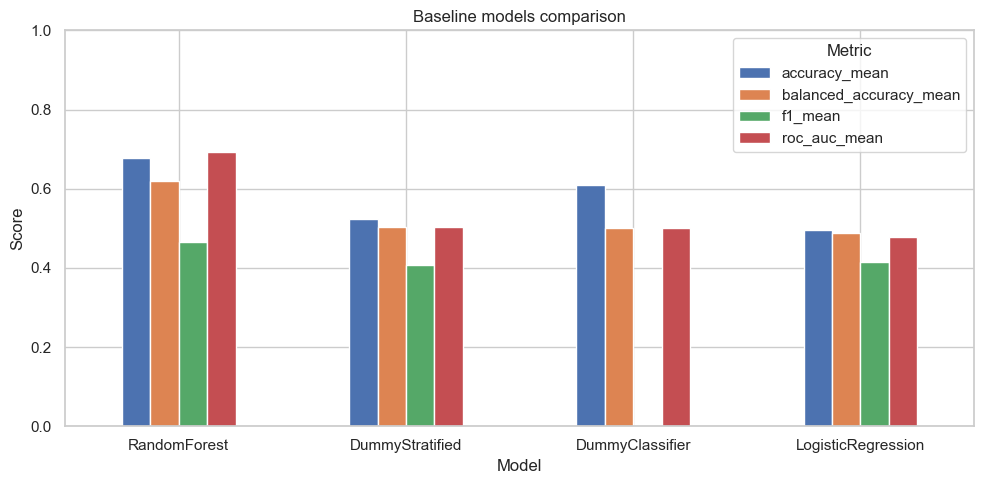

In [28]:
metrics_to_plot = [
    "accuracy_mean",
    "balanced_accuracy_mean",
    "f1_mean",
    "roc_auc_mean"
]

ax = cv_comparison[metrics_to_plot].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Baseline models comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 12. Выбор лучшей baseline-модели

На baseline-этапе в качестве лучшей модели обычно выбираем модель с лучшими значениями:

- `balanced_accuracy_mean`;
- `roc_auc_mean`;
- `f1_mean`.

Ниже автоматически выбираем лучшую модель по `balanced_accuracy_mean`.

In [19]:
best_model_name = cv_comparison.index[0]

pipelines = {
    "DummyClassifier": dummy_pipeline,
    "LogisticRegression": logreg_pipeline,
    "RandomForest": rf_pipeline
}

best_pipeline = pipelines[best_model_name]

print("Best baseline model:", best_model_name)

Best baseline model: RandomForest


## 13. Обучение лучшей baseline-модели и test evaluation

Обучаем лучшую baseline-модель на всём train и оцениваем на test.

In [20]:
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

if hasattr(best_pipeline.named_steps["model"], "predict_proba"):
    y_proba = best_pipeline.predict_proba(X_test)[:, 1]
else:
    y_proba = None

test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0)
}

if y_proba is not None:
    test_metrics["roc_auc"] = roc_auc_score(y_test, y_proba)

test_metrics_df = pd.DataFrame(test_metrics, index=["test"]).T

display(test_metrics_df)

print(classification_report(y_test, y_pred, zero_division=0))

,test
accuracy,0.6616
balanced_accuracy,0.6037
precision,0.6214
recall,0.3398
f1,0.4394
roc_auc,0.6607


              precision    recall  f1-score   support

           0       0.67      0.87      0.76       400
           1       0.62      0.34      0.44       256

    accuracy                           0.66       656
   macro avg       0.65      0.60      0.60       656
weighted avg       0.65      0.66      0.63       656



Главная проблема, что модель хорошо находит класс 0, но плохо находит класс 1.

## 14. Confusion Matrix

Матрица ошибок показывает, какие ошибки делает модель.

Для задачи Water Potability важно понимать:

- сколько непригодной воды ошибочно признано пригодной;
- сколько пригодной воды ошибочно признано непригодной.

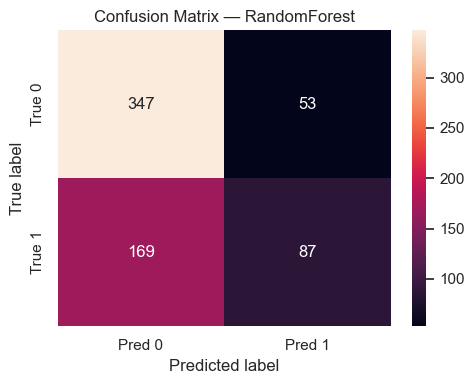

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"]
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

## 15. ROC и Precision-Recall curves

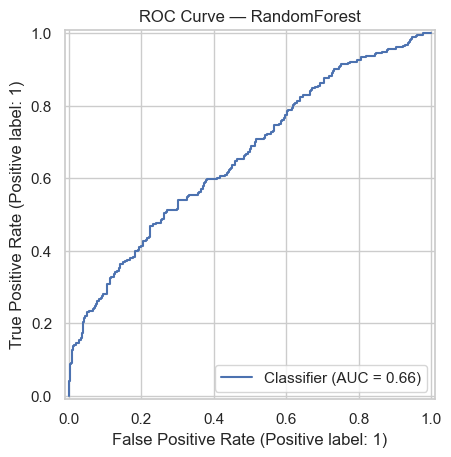

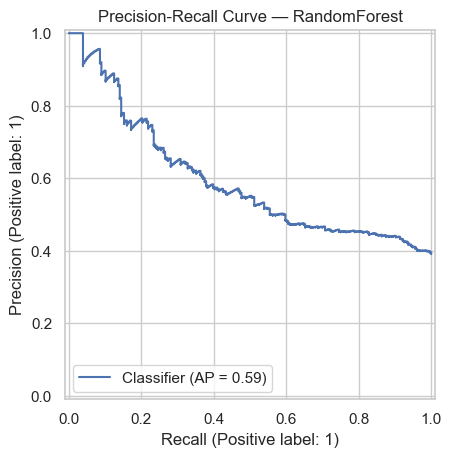

In [25]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f"ROC Curve — {best_model_name}")
plt.grid(True)
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title(f"Precision-Recall Curve — {best_model_name}")
plt.grid(True)
plt.show()


## 16. Feature importance для Random Forest

,feature,importance
0,ph,0.1343
4,Sulfate,0.1279
1,Hardness,0.1211
3,Chloramines,0.1163
2,Solids,0.1132
5,Conductivity,0.0994
8,Turbidity,0.0980
6,Organic_carbon,0.0968
7,Trihalomethanes,0.0929


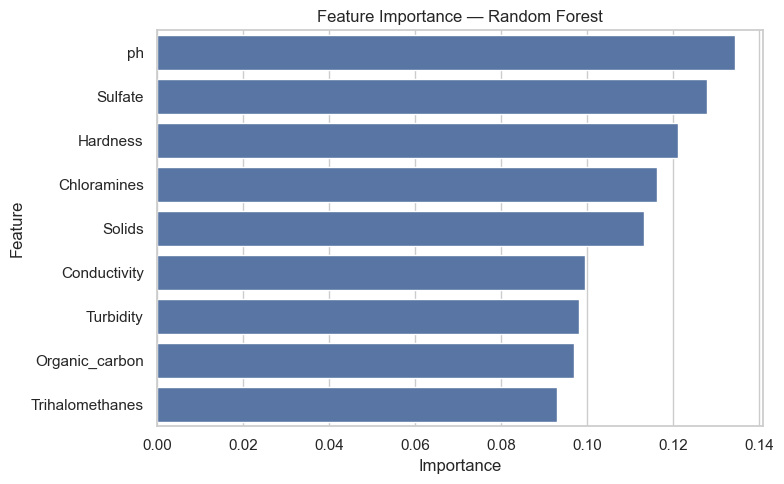

In [24]:
rf_model = best_pipeline.named_steps["model"]

feature_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

display(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature"
)
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Выводы по baseline-моделям

На baseline-этапе были рассмотрены четыре модели: DummyClassifier (most frequent), DummyClassifier (stratified), LogisticRegression и RandomForest.

DummyClassifier (most frequent) показал accuracy около 0.61, но полностью игнорирует класс 1 (recall = 0), поэтому не является пригодным решением.

DummyStratified даёт более честный baseline: balanced accuracy ≈ 0.50 и ROC-AUC ≈ 0.50, что соответствует случайному угадыванию.

LogisticRegression не улучшает качество относительно случайного baseline (ROC-AUC ≈ 0.48), что подтверждает отсутствие линейной зависимости между признаками и целевой переменной.

Лучшей baseline-моделью оказался RandomForest:
- balanced accuracy ≈ 0.62 (CV)
- ROC-AUC ≈ 0.69 (CV)
- ROC-AUC ≈ 0.66 (test)

Это показывает, что модель извлекает полезный сигнал из данных за счёт нелинейностей.

Однако модель имеет перекос в сторону класса 0:
recall для класса 1 остаётся низким (~0.34), что означает плохое обнаружение пригодной воды.

### Итог

- Линейные модели не подходят для задачи
- В данных есть слабый, но реальный нелинейный сигнал
- RandomForest задаёт базовый уровень качества
- Основное направление улучшений — более мощные нелинейные модели и работа с recall класса 1